In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle as pkl
import arviz as az

In [71]:
import pymc as pm

In [72]:
pm.__version__

'5.16.2'

In [30]:
with open('llt.cu01.TP53.P112A.chain.pkl', 'rb') as buff:
    idata = pkl.load(buff)

array([[<Axes: title={'center': 'aoo'}>,
        <Axes: title={'center': 'aoo'}, xlabel='Rank (all chains)', ylabel='Chain'>],
       [<Axes: title={'center': 'fitness'}>,
        <Axes: title={'center': 'fitness'}, xlabel='Rank (all chains)', ylabel='Chain'>]],
      dtype=object)

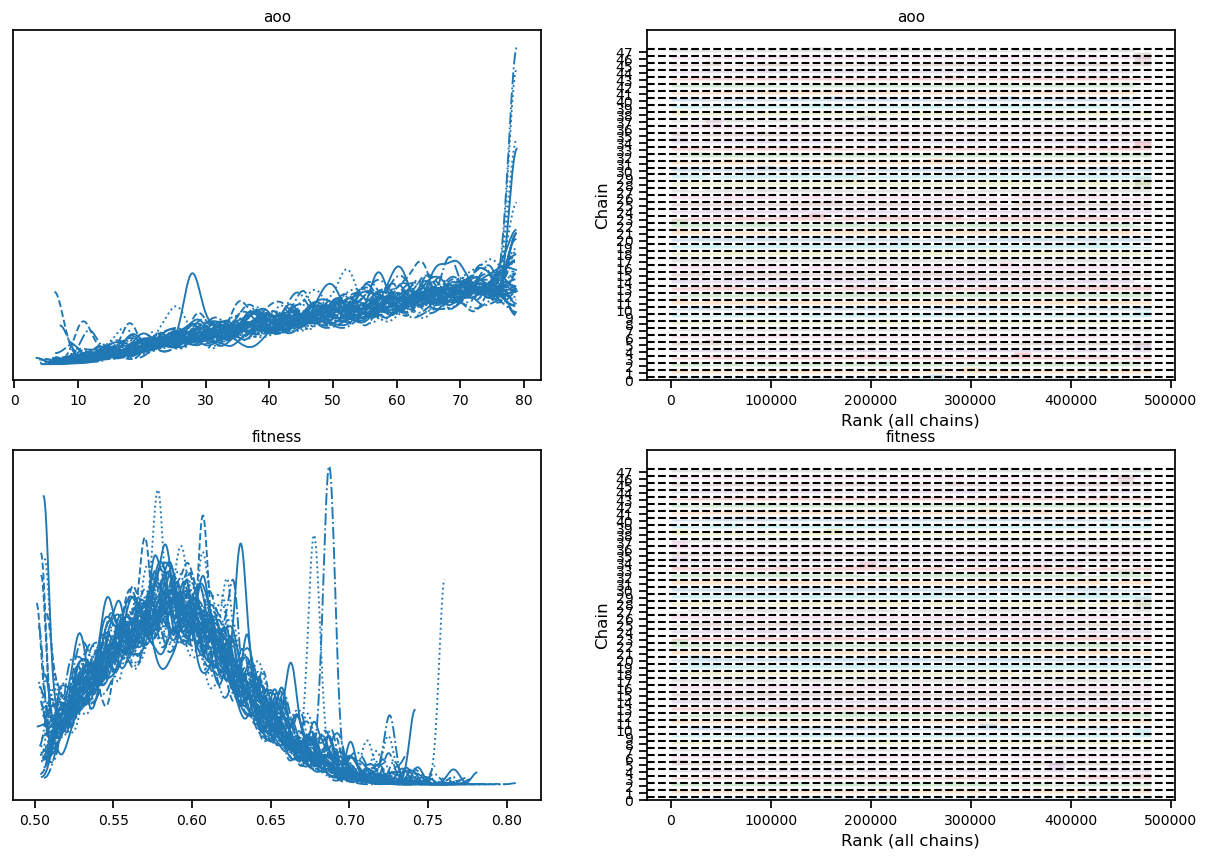

In [31]:
az.plot_trace(idata, kind="rank_bars", figsize=(15, 10))

array([<Axes: title={'center': 'aoo'}>,
       <Axes: title={'center': 'fitness'}>], dtype=object)

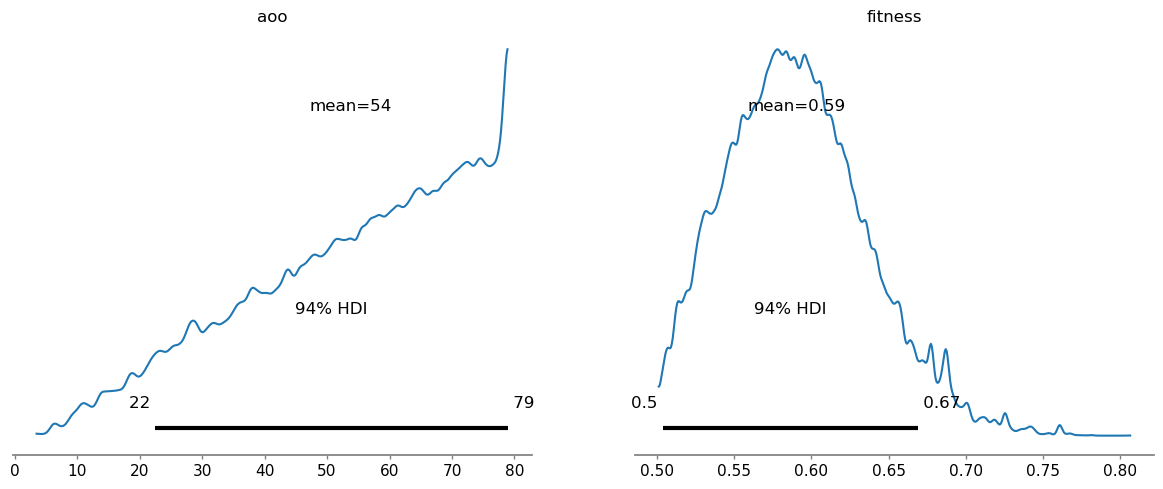

In [32]:
az.plot_posterior(idata)

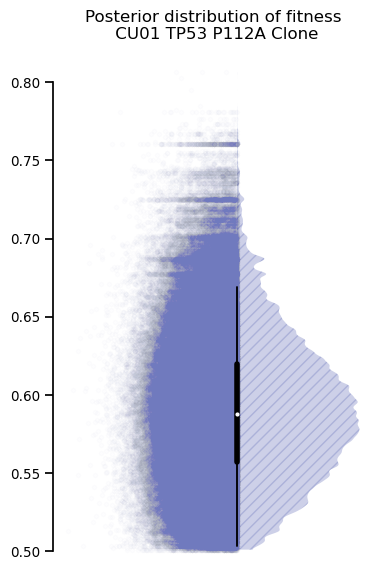

In [33]:
sns.set_context('notebook')
az.plot_violin(
    idata,
    var_names=["fitness"],
    figsize=(4, 6),
    sharey=False,
    sharex=False,
    rug=True,
    #rug_kwargs={"color": "#5d8aa8", 'alpha': 0.005},
    rug_kwargs={"color": '#707abe', 'alpha': 0.01},
    shade_kwargs={"color": '#707abe', 'hatch': '///'},
)
plt.title("Posterior distribution of fitness\n CU01 TP53 P112A Clone")
#plt.ylim(0.5, 0.6)
sns.despine(trim=True, bottom=True)
plt.tight_layout()
#plt.savefig('fitness-posterior-JAK2R683S_2.png', dpi=300, bbox_inches='tight', transparent=True)

array([<Axes: title={'center': '94.0% HDI'}>,
       <Axes: title={'center': 'ess'}>], dtype=object)

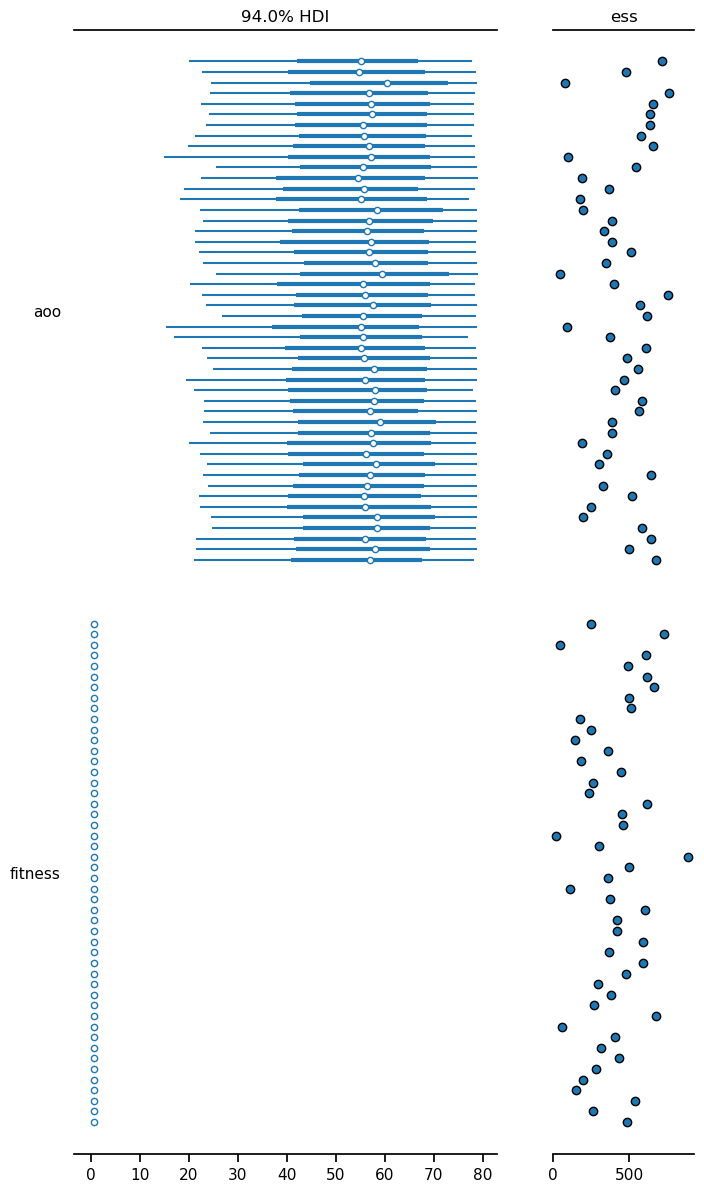

In [41]:
az.plot_forest(idata, ess=True,)

array([<Axes: >], dtype=object)

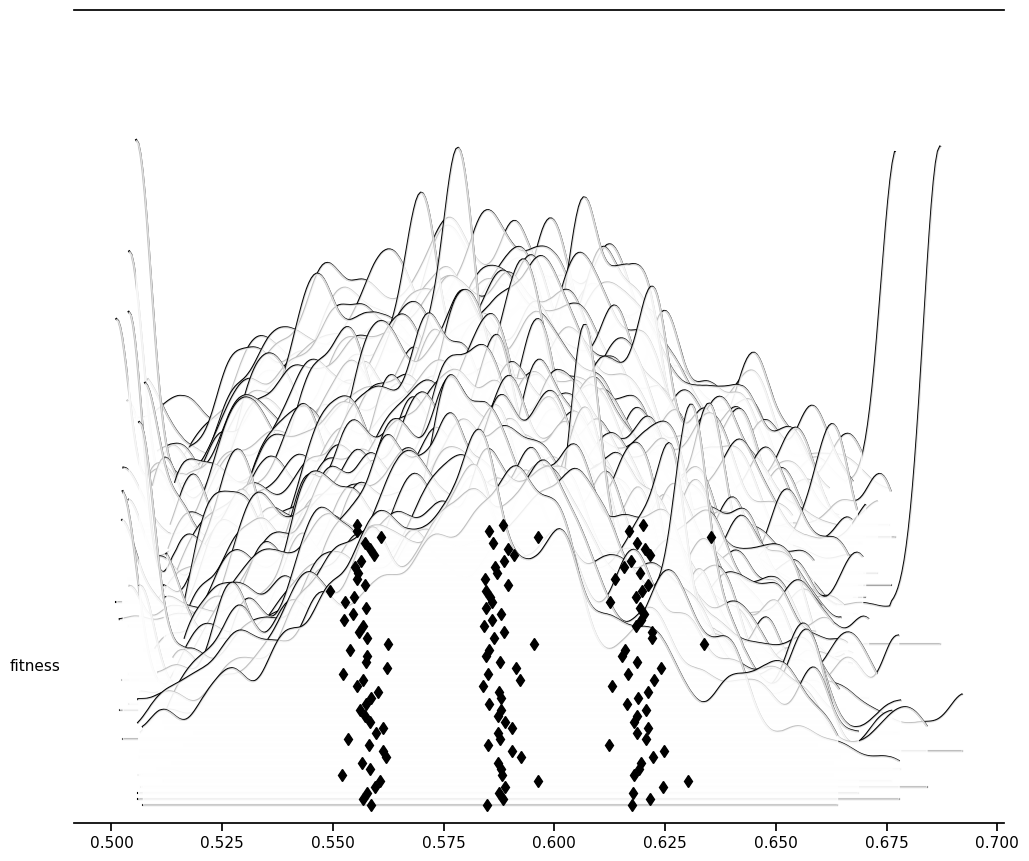

In [69]:
az.plot_forest(
    idata,
    kind='ridgeplot',
    var_names=['fitness'],
    combined=False,
    ridgeplot_overlap=0.8,
    ridgeplot_alpha=0.75,
    ridgeplot_truncate=True,
    ridgeplot_quantiles=[0.25, 0.5, 0.75],
    colors='white'
)

array([<Axes: title={'center': 'aoo'}, xlabel='Total number of draws', ylabel='ESS'>,
       <Axes: title={'center': 'fitness'}, xlabel='Total number of draws', ylabel='ESS'>],
      dtype=object)

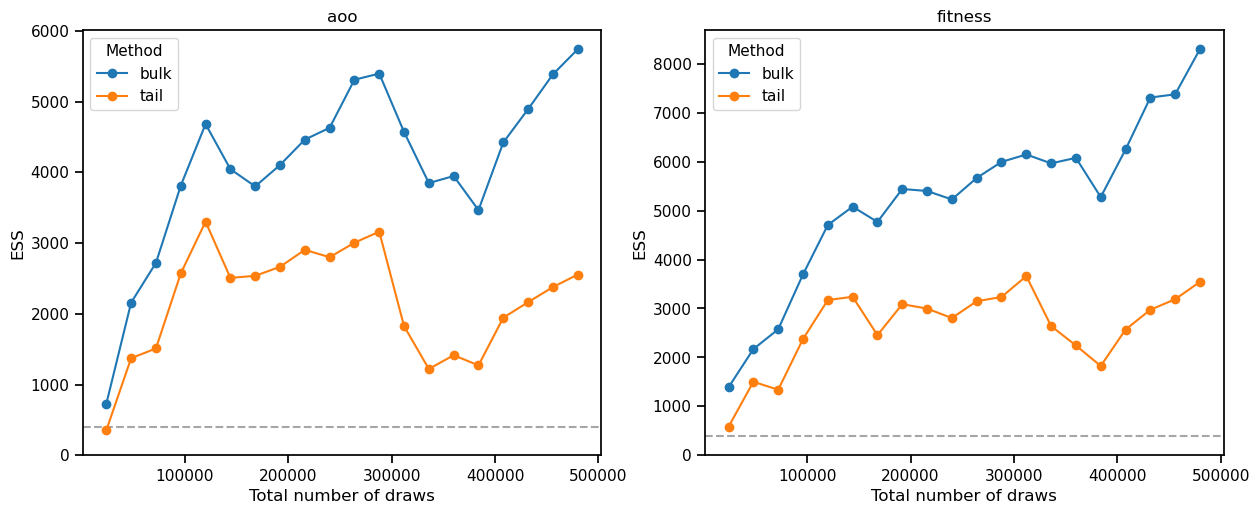

In [35]:
az.plot_ess(idata, kind='evolution')

array([[<Axes: >, None],
       [<Axes: xlabel='aoo', ylabel='fitness'>, <Axes: >]], dtype=object)

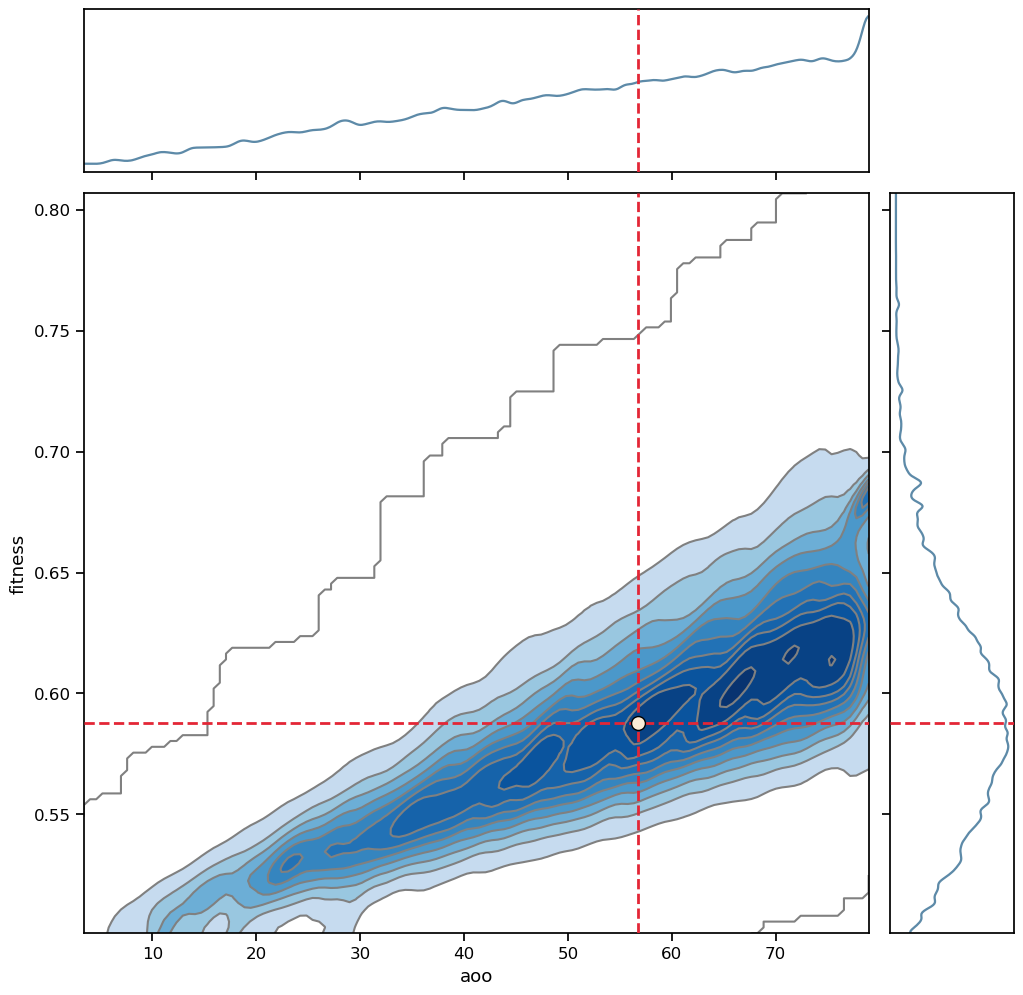

In [36]:
az.plot_pair(
    idata,
    var_names=['aoo', 'fitness', ],
    marginals=True,
    kind='kde',
    figsize=(12, 12),
    textsize=12,
    colorbar=True,
    point_estimate='median',
    point_estimate_kwargs={'color': '#e32636', 'linestyle': '--', 'linewidth': 2, 'zorder': 3},
    point_estimate_marker_kwargs = {'color': '#faebd7', 'zorder': 3, 's': 100, 'marker': 'o', 'alpha': 1, 'edgecolor': 'k'},
    marginal_kwargs={'color': '#5d8aa8',},
    kde_kwargs={'hdi_probs':list(np.arange(0.01,0.99,0.1)), 'contourf_kwargs': {'cmap': 'Blues', }},    
)


In [70]:
idata

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

In [ ]:
sns.set_context('notebook')
az.plot_violin(
    idata,
    var_names=["fitness"],
    figsize=(4, 6),
    sharey=False,
    sharex=False,
    rug=True,
    #rug_kwargs={"color": "#5d8aa8", 'alpha': 0.005},
    rug_kwargs={"color": '#707abe', 'alpha': 0.01},
    shade_kwargs={"color": '#707abe', 'hatch': '///'},
)
plt.title("Posterior distribution of fitness\n ESO29 TP53 G227X Clone")
plt.ylim(0.5, 0.6)
sns.despine(trim=True, bottom=True)
plt.tight_layout()


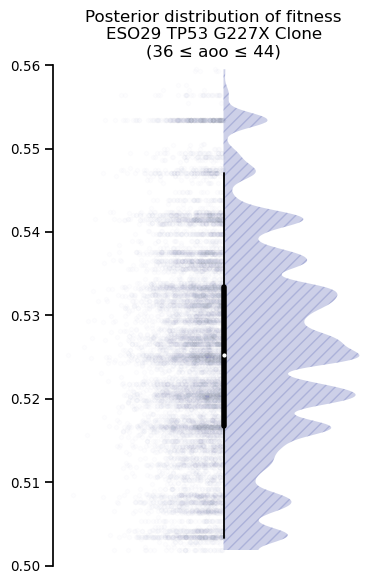

In [18]:
filtered_idata = az.extract(idata, group="posterior")
mask = (filtered_idata['aoo'] >= 36) & (filtered_idata['aoo'] <= 44)
filtered_fitness = filtered_idata['fitness'][mask]

# Create a new InferenceData object with the filtered data
filtered_idata_new = az.InferenceData(
    posterior=az.dict_to_dataset({"fitness": filtered_fitness.values})
)

# Plot the violin plot with the filtered data
sns.set_context('notebook')
az.plot_violin(
    filtered_idata_new,
    var_names=["fitness"],
    figsize=(4, 6),
    sharey=False,
    sharex=False,
    rug=True,
    rug_kwargs={"color": '#707abe', 'alpha': 0.01},
    shade_kwargs={"color": '#707abe', 'hatch': '///'},
)
plt.title("Posterior distribution of fitness\nESO29 TP53 G227X Clone\n(36 ≤ aoo ≤ 44)")
plt.ylim(0.5, 0.56)
sns.despine(trim=True, bottom=True)
plt.tight_layout()
plt.show()